# TenSEAL Implementation ML - One

In [1]:
import torch
import time
from torchvision import datasets
import torchvision.transforms as transforms
import numpy as np
import tenseal as ts
import matplotlib.pyplot as plt

### Load Data

- Sets fixed random seed for reproducibility
- Defines batch size for data loading during training and testing
- Loads MNIST training/testing dataset (downloads if not present and converts images to tensors)
- Wraps the training/testing dataset in a DataLoader (loads data in mini-batches, shuffles the data at each epoch)

In [2]:
torch.manual_seed(73) #fixed random seed
batch_size = 64 #batch size for data loading during train/test

#download MNIST train/test datasets
train_data = datasets.MNIST('data', train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.MNIST('data', train=False, download=True, transform=transforms.ToTensor())

#wraps train/test dataset in dataloader
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

Evaluate number of training and testing samples from train/test split

In [ ]:
num_training = len(train_data)
num_testing = len(test_data)

print("Number of training: ", num_training)
print("Number of testing: ", num_testing)

Number of training:  60000
Number of testing:  10000


Display data (image/label) to get evaluation of classification

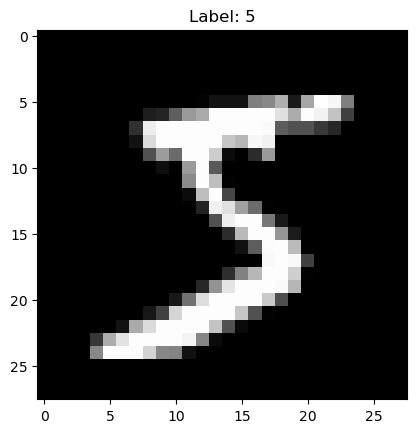

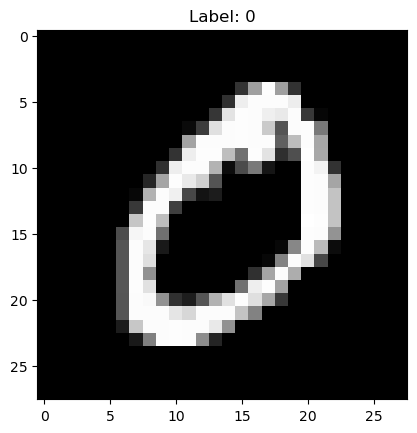

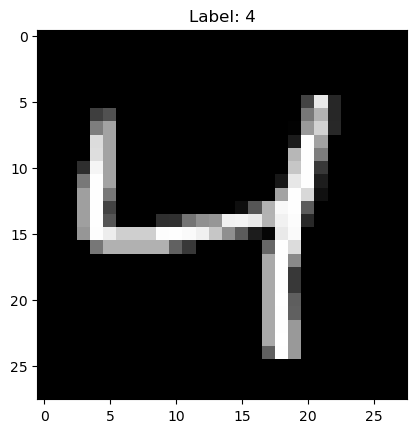

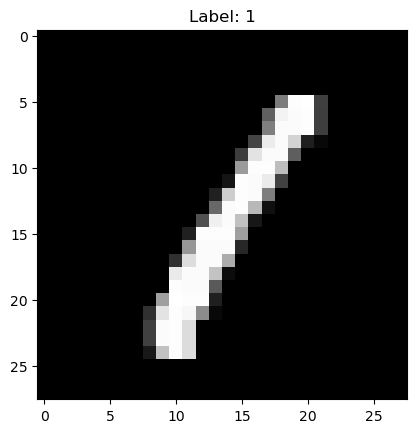

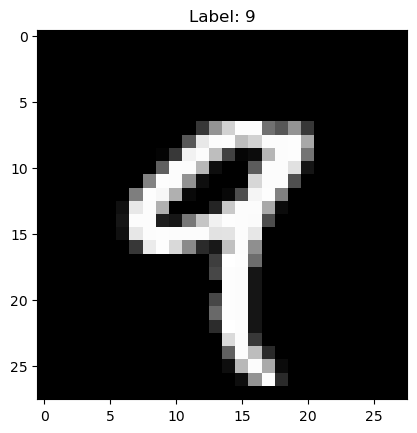

In [4]:
for i in range(5):
    image, label = train_data[i]
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.show()

## Non-Encrypted Model Pipeline

### Define CNN Model Compatible with FHE

- INIT: Convolution Layer 1 (conv1) -> Input 1 channel, output 4 channels
- INIT: Fully Connected Layer 1 (fc1) -> input 256, output 64
- INIT: Output Fully COnnected Layer (fc2) -> Input 64, output 10
- FORWARD: Applies convolution
- FORWARD: Applies square activation function (instead of ReLU for HE-compatibility)
- FORWARD: Flatten tensor to shape for fully connected layer
Square activation is used so it can be later implemented in encryption form

In [5]:
class ConvNet(torch.nn.Module):
    def __init__(self, hidden=64, output=10):
        super(ConvNet, self).__init__()        
        self.conv1 = torch.nn.Conv2d(1, 4, kernel_size=7, padding=0, stride=3)
        self.fc1 = torch.nn.Linear(256, hidden)
        self.fc2 = torch.nn.Linear(hidden, output)

    def forward(self, x):
        x = self.conv1(x)
        x = x * x
        x = x.view(-1, 256)
        x = self.fc1(x)
        x = x * x
        x = self.fc2(x)
        return x

### Training Non-Encrypted Model

- Initializes the model
- Defines the loss function for multi-class classification
- Defines optimizer (Adam)
- Sets the model to training mode
- Trains for 10 epochs
- Iterate through each batch in the training DataLoader
- Clear gradients from previous step
- Forward pass: compute predicted outputs
- Compute the loss between predictions and actual labels
- Backward pass: compute gradients
- Update model weights
- Accumulate batch loss
- Compute average loss over all batches in this epoch
- Sets model to evaluation mode (disables dropout, batchnorm)

In [6]:
model = ConvNet()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model.train()
for epoch in range(1, 11):

    train_loss = 0.0
    for data, target in train_loader:
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)

    print('Epoch: {} \tTraining Loss: {:.6f}'.format(epoch, train_loss))

model.eval()

Epoch: 1 	Training Loss: 0.397561
Epoch: 2 	Training Loss: 0.130699
Epoch: 3 	Training Loss: 0.088399
Epoch: 4 	Training Loss: 0.071318
Epoch: 5 	Training Loss: 0.058989
Epoch: 6 	Training Loss: 0.050542
Epoch: 7 	Training Loss: 0.044438
Epoch: 8 	Training Loss: 0.038258
Epoch: 9 	Training Loss: 0.034622
Epoch: 10 	Training Loss: 0.031742


ConvNet(
  (conv1): Conv2d(1, 4, kernel_size=(7, 7), stride=(3, 3))
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

### Testing Encrypted Model

- Initialize test loss and accuracy tracking per class
- Set model to evaluation mode (disables dropout, batchnorm)
- Loop through test data in batches
- Forward pass: compute predictions
- Compute loss for this batch and acculate
- Get predicted class (index of max logit)
- Compare predictions to true labels
- Count correct predictions per class
- Calculates average test loss across all batches then prints accuracy
- Prints overall accuracy across all classes

In [ ]:
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval()

for data, target in test_loader:
    output = model(data)
    loss = criterion(output, target)
    test_loss += loss.item()
    _, pred = torch.max(output, 1)
    correct = np.squeeze(pred.eq(target.data.view_as(pred)))
    for i in range(len(target)):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

test_loss = test_loss/len(test_loader)
print(f'Test Loss: {test_loss:.6f}\n')

for label in range(10):
    print(
        f'Test Accuracy of {label}: {int(100 * class_correct[label] / class_total[label])}% '
        f'({int(np.sum(class_correct[label]))}/{int(np.sum(class_total[label]))})'
    )

print(
    f'\nTest Accuracy (Overall): {int(100 * np.sum(class_correct) / np.sum(class_total))}% ' 
    f'({int(np.sum(class_correct))}/{int(np.sum(class_total))})'
)

Test Loss: 0.072263

Test Accuracy of 0: 98% (969/980)
Test Accuracy of 1: 99% (1129/1135)
Test Accuracy of 2: 98% (1013/1032)
Test Accuracy of 3: 99% (1000/1010)
Test Accuracy of 4: 98% (969/982)
Test Accuracy of 5: 98% (877/892)
Test Accuracy of 6: 98% (945/958)
Test Accuracy of 7: 97% (1006/1028)
Test Accuracy of 8: 97% (954/974)
Test Accuracy of 9: 95% (967/1009)

Test Accuracy (Overall): 98% (9829/10000)
